In [1]:
import pandas as pd

In [11]:
df = pd.read_csv('./Financial_data.csv')
df = df.dropna(subset=['Company', 'Year'])

numeric_cols = ['Total Revenue', 'Net Income', 'Total Assets', 'Total Liabilities', 'Cash Flow from Operating Activities']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')
    
df = df.sort_values(by=['Company', 'Year']).reset_index(drop=True)

In [ ]:
df['Revenue Growth (%)'] = df.groupby('Company')['Total Revenue'].pct_change() * 100
df['Net Income Growth (%)'] = df.groupby('Company')['Net Income'].pct_change() * 100

print("--- Cleaned DataFrame with Growth Rates ---")
print(df[['Company', 'Year', 'Total Revenue', 'Revenue Growth (%)', 'Net Income', 'Net Income Growth (%)']])

--- Reordered DataFrame ---
     Company    Year  Total Revenue  Revenue Growth (%)  Net Income  \
0      Apple  2023.0         383285                 NaN       96995   
1      Apple  2024.0         391035            2.021994       93736   
2      Apple  2025.0         416161            6.425512      112010   
3  Microsoft  2023.0         211915                 NaN       72361   
4  Microsoft  2024.0         245122           15.669962       88136   
5  Microsoft  2025.0         281724           14.932156      101832   
6      Tesla  2023.0          96773                 NaN       14974   
7      Tesla  2024.0          97690            0.947578        7153   
8      Tesla  2025.0          94827           -2.930699        3855   

   Net Income Growth (%)  Total Assets  Total Liabilities  \
0                    NaN        352583             290437   
1              -3.359967        364980             308030   
2              19.495178        359241             285508   
3                

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

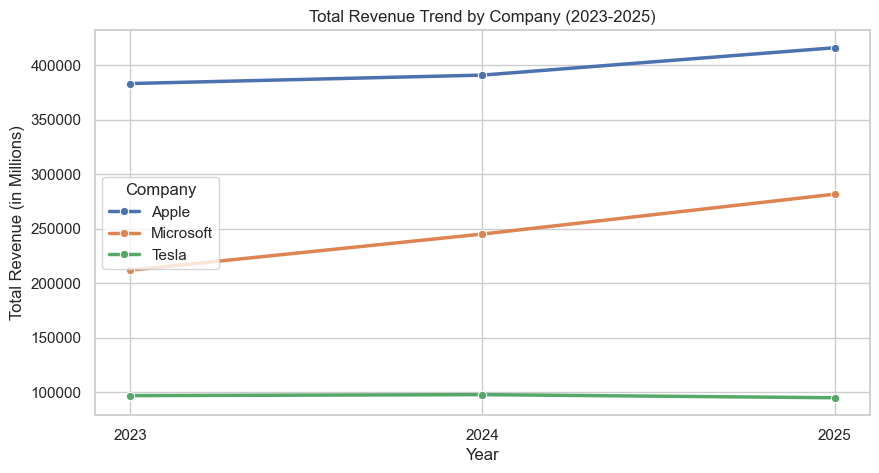

In [17]:
df['Year'] = df['Year'].astype(int)

plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Year', y='Total Revenue', hue='Company', marker='o', linewidth=2.5)

plt.title('Total Revenue Trend by Company (2023-2025)')
plt.xlabel('Year')
plt.ylabel('Total Revenue (in Millions)')

plt.xticks([2023, 2024, 2025])

plt.legend(title='Company')
plt.show()

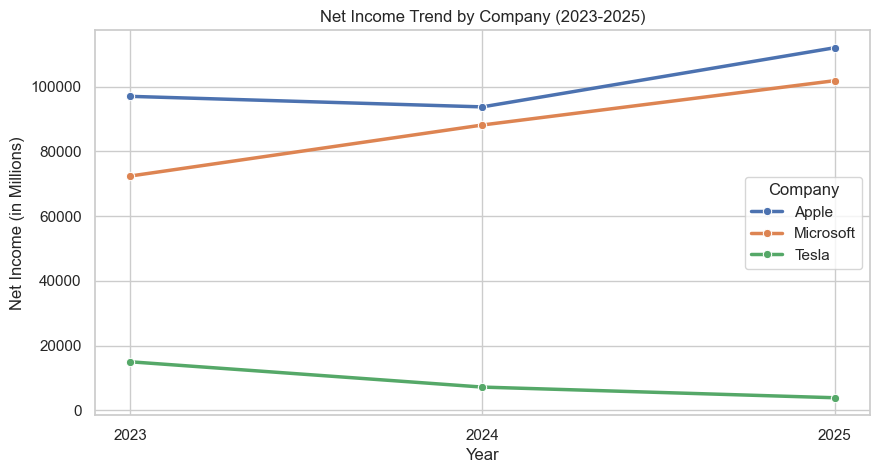

In [18]:
# Net Income Trend Line Plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Year', y='Net Income', hue='Company', marker='o', linewidth=2.5)

plt.title('Net Income Trend by Company (2023-2025)')
plt.xlabel('Year')
plt.ylabel('Net Income (in Millions)')
plt.xticks([2023, 2024, 2025])
plt.legend(title='Company')
plt.show()

In [19]:
# Total sum of market metrics by year
yearly_market_summary = df.groupby('Year')[['Total Revenue', 'Net Income']].sum()
print("\n--- Yearly Market Summary (Total of 3 Companies) ---")
print(yearly_market_summary)


--- Yearly Market Summary (Total of 3 Companies) ---
      Total Revenue  Net Income
Year                           
2023         691973      184330
2024         733847      189025
2025         792712      217697


In [20]:
# Statistical summary by company using agg()
company_stats = df.groupby('Company')['Total Revenue'].agg(['mean', 'max', 'min', 'std'])
print("\n--- Revenue Statistics by Company ---")
print(company_stats)


--- Revenue Statistics by Company ---
                    mean     max     min           std
Company                                               
Apple      396827.000000  416161  383285  17186.282088
Microsoft  246253.666667  281724  211915  34918.256290
Tesla       96430.000000   97690   94827   1461.994870


## Quantitative Financial Performance Report (2023-2025)

#1 Apple : Stable Growth & Strong Profit Rebound
* Revenue Performance : Total revenue steadily increased from $383,285M in 2023 to $391,035M in 2024 (2.02% growth), and further expanded to $416,161M in 2025 (6.42% growth), maintaining the highest average revenue of $396,827M

* Net Income & Profitability : Net income shifted from $96,995M in 2023 to $93,736M in 2024 (-3.36% decline), before experiencing a strong rebound to $112,010M in 2025 with a 19.50% surge.



#2 Microsoft : Consistent Double-Digit Growth
* Revenue Performance : Achieved powerful consecutive top-line growth, rising from $211,915M in 2023 to $245,122M in 2024 (15.67% growth), and reaching $281,724M in 2025 (14.93% growth).

* Net Income & Profitability : Net income grew significantly from $72,361M in 2023 to $88,136M in 2024 (21.80% growth), and continued upward to $101,832M in 2025 (15.54% growth),demonstrating high operational efficiency.



#3 Tesla : Revenue Flatness and Earnings Contraction
* Revenue Performance : Revenue remained largely stagnant, recording $96,773M in 2023, $97,690M in 2024 (0.95% growth), and slightly declining to $94,827M in 2025 (-2.93% decline), with an average revenue of $96,430M.

* Net Income & Profitability : Experienced a severe contraction in net income, dropping from $14,974M in 2023 down to $7,153M in 2024 (-52.23% decline), and further down to $3,855M in 2025 (-46.11% decline).


## Combined Market Aggregates (2023-2025)
* Total Market Revenue : The combined revenue of the three tech giants expanded from $691,973M in 2023 to $733,847M in 2024 and $792,712M in 2025, showing continuous macro-level growth.

* Total Market Net Income : Combined net income scaled from $184,330M in 2023 to $189,025M in 2024 and $217,697M in 2025